# **Züri wie neu Reports Category Analysis**

Author: Tim Berger  
Date: 22.5.2026
<br>
<br>

### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city.  
Reports are sorted in different categories, such as waste or graphity.  
To find out which categories of the infrastructure experiences the most damage that bothers the residents of Zürich, the categories can be analyzed based on the number of reports they contain. 
<br>
<br>

### Research Question: 
Which categories of the infrastructure of Zürich experiences the most damage that bothers the residents?
<br>
<br>

### Requirements
See README file
<br>
<br>

### **Import Required Packages and Scripts**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

import notebook_utils

### **Load Data from the Website of the City of Zürich**

In [ ]:
# the notebook_utils file contains the functions to load the required data
# if a dataset failed to load, the corresponding url should be checked
# the source and explanation of the url can be found in the README file.

url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"

zwn_gdf_raw = notebook_utils.import_geografic_data(url_zwn)


data loaded successfully


### **Clean and Filter the Data**

In [13]:
# filter for the required columns
zwn_df = zwn_gdf_raw[["service_request_id", "title", "service_name", "requested_datetime"]].copy()

# print dates of the oldest and newest report
print(f"The data contains reports from the {min(zwn_df["requested_datetime"]).date().strftime("%d/%m/%Y")} to the {max(zwn_df["requested_datetime"]).date().strftime("%d/%m/%Y")}.")

# have a look if everything worked and if there are NA values
zwn_df.info()

The data contains reports from the 14/03/2013 to the 21/05/2026.
<class 'pandas.DataFrame'>
RangeIndex: 73343 entries, 0 to 73342
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   service_request_id  73343 non-null  str           
 1   title               73343 non-null  str           
 2   service_name        73343 non-null  str           
 3   requested_datetime  73343 non-null  datetime64[ms]
dtypes: datetime64[ms](1), str(3)
memory usage: 4.7 MB


### **Agregate and Normalize**

- agregate the data to have the number of reports per category

In [10]:
#count the reports per category and safe it as a dataframe
zwn_categories = zwn_df["service_name"].value_counts().copy().to_frame()

#rename the column and index
zwn_categories = zwn_categories.rename(columns={"count":"count_reports"}, index={"service_name": "category"})


- normalize counts per year

In [11]:
# calculate the time between the oldest and newest report
time_diff = max(zwn_df["requested_datetime"])- min(zwn_df["requested_datetime"])

#add a column with the reports per year
zwn_categories["reports_per_day"] = round(zwn_categories["count_reports"] / time_diff.days, 2)

# check the top of the table
zwn_categories.head(5)

,count_reports,reports_per_day
service_name,,
Abfall/Sammelstelle,27670,5.75
Signalisation/Lichtsignal,11061,2.30
Strasse/Trottoir/Platz,9924,2.06
Grünflächen/Spielplätze,7310,1.52
Beleuchtung/Uhren,5430,1.13


## **Plot Data**

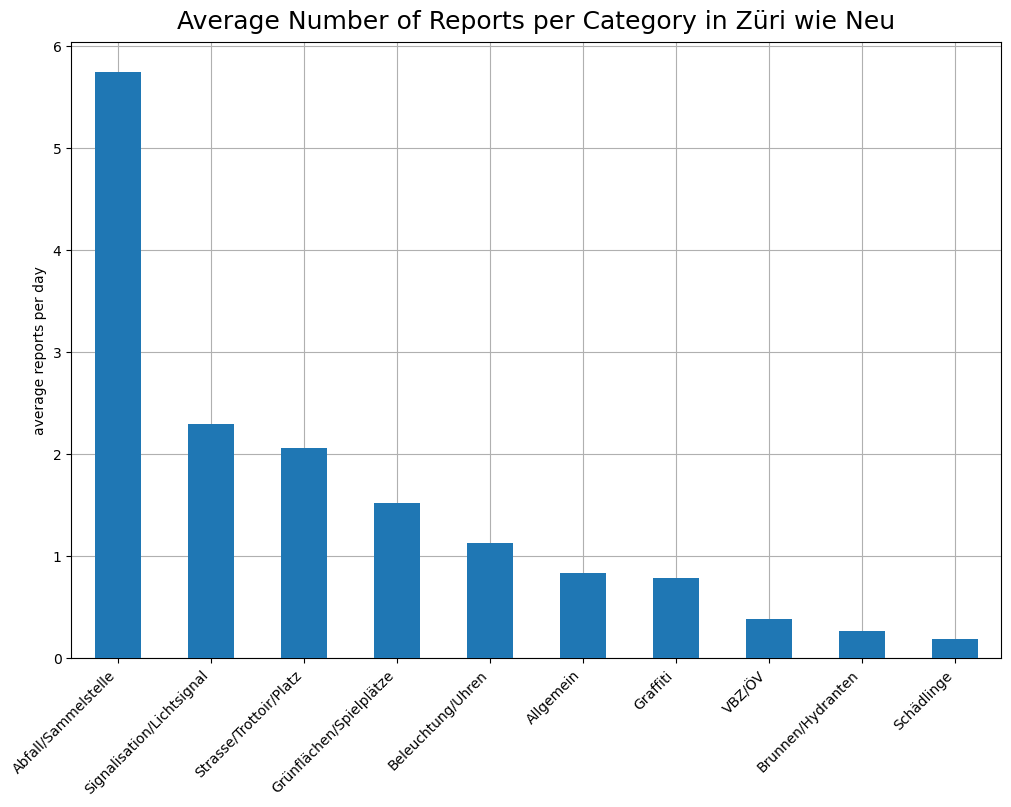

In [12]:
fig, ax = plt.subplots(figsize = (12,8))




#plot the reports per category as a barplot
zwn_categories["reports_per_day"].plot(kind="bar", ax=ax,
                                       xlabel="",
                                       ylabel="average reports per day",
                                       zorder= 10)

#set title
ax.set_title("Average Number of Reports per Category in Züri wie Neu", fontsize=18, pad=10)

#rotate neighbourhood labels on the x axis
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")

ax.grid(True, zorder=0)

# save figure in the figures folder
fig.savefig("../figures/reports_categories_bar.png", dpi=300, bbox_inches="tight")

# show plot
plt.show()

### **Results**

The 'Waste/Collection Site' category contains by far the most reports, with an average of almost 6 reports per day.  
The second most frequent category is 'Signalisation/Traffic Light' with over 2 reports per day.  
From the second to the smallest category, 'Vermin', there is about a linear decrease in reports per category.